# _Devaneios Maquinários - APS2_
# Luizettp

### Importando Bibliotecas

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import glob

from IPython.display import clear_output

__________
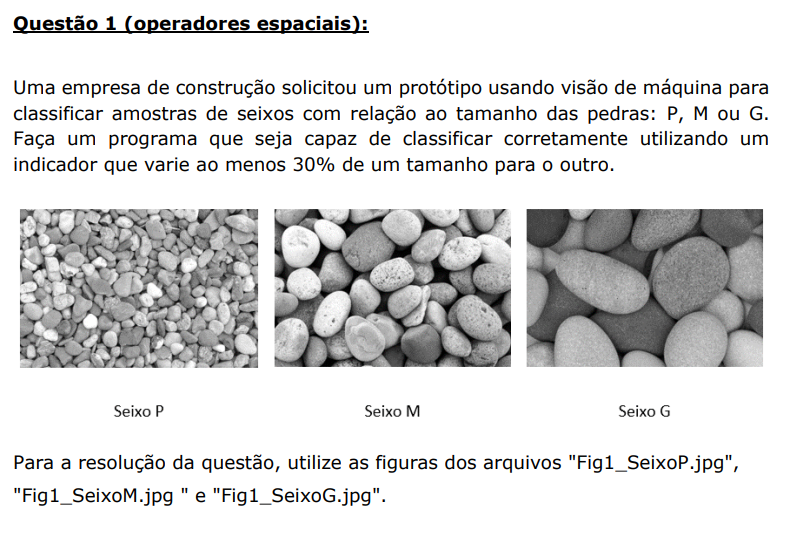


Shape da imagem P = (464, 700)
Shape da imagem M = (467, 700)
Shape da imagem G = (467, 700)

--- Indicadores encontrados ---
Indicador da imagem P = 0.20653633004926109
Indicador da imagem M = 0.1298623432242276
Indicador da imagem G = 0.0668950749464668

--- Variações percentuais ---
Variação entre P e M = 37.12%
Variação entre M e G = 48.49%
Variação entre P e G = 67.61%

--- Indicadores em ordem decrescente ---
P -> 0.20653633004926109
M -> 0.1298623432242276
G -> 0.0668950749464668

--- Resultado da classificação ---
Fig1_SeixoP.jpg -> P
Fig1_SeixoM.jpg -> M
Fig1_SeixoG.jpg -> G


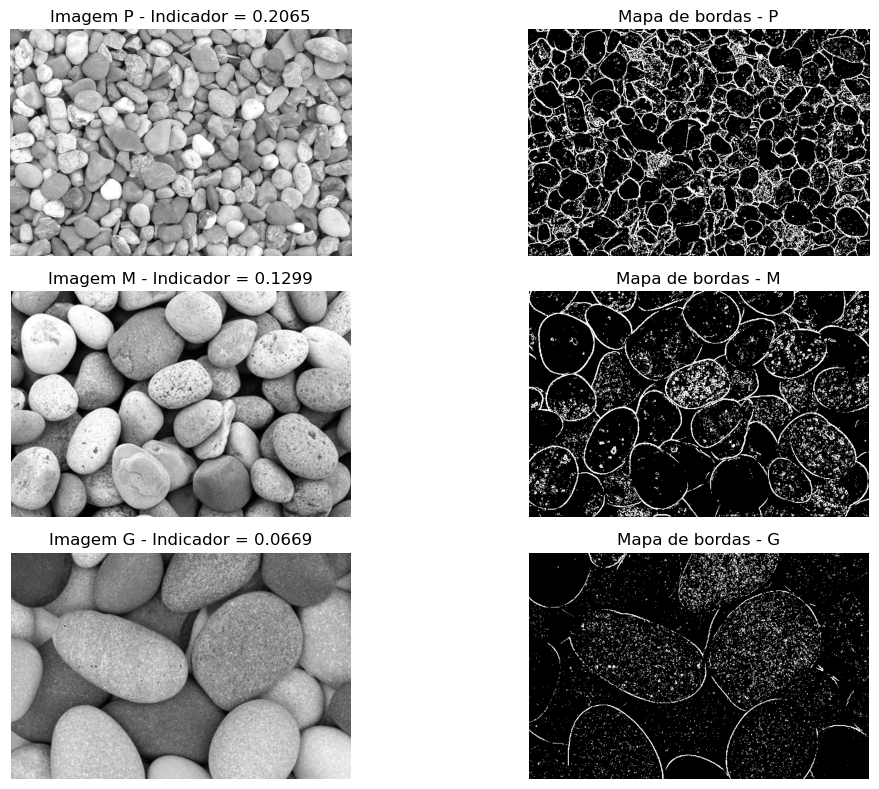

A imagem teste foi classificada como: M


In [3]:
# ============================================================
# Exercício 1
# Classificar seixos em P, M e G usando um operador espacial
# ============================================================


limiar =  30   # Limiar é que diferença entre pixels significamos como borda.

# ============================================================
# 1) Função para ler a imagem e garantir que ela vire cinza, SUPREMA.
# ============================================================
def LerImagemCinza(caminho):
    """
    Lê a imagem do arquivo.

    Se ela vier colorida (RGB), transformamos em tons de cinza
    fazendo a média dos 3 canais.

    No fim, devolvemos uma matriz 2D do tipo uint8.
    """

    img = mpimg.imread(caminho)

    # Se a imagem tiver 3 dimensões, então ela veio colorida
    if len(img.shape) == 3:
        # Pegamos só os 3 primeiros canais e fazemos a média
        img_cinza = np.mean(img[:, :, :3], axis=2)
    else:
        # Se já veio em cinza, só copiamos
        img_cinza = img.copy()

    return img_cinza.astype(np.uint8)


# ============================================================
# 2) Função para calcular o indicador da imagem. Limiar é que diferença entre pixels significa borda.
# ============================================================
def CalcularIndicador(img_u8, limiar):
    """
    Ideia do indicador:
    - Seixos pequenos devem gerar mais mudanças rápidas de intensidade, obviamente
    - Vamos medir isso com diferenças horizontais e verticais

    Logo;
    1) Percorrer a imagem
    2) Calcular diferença absoluta entre pixels vizinhos
    3) Somar as respostas horizontal e vertical
    4) Marcar como borda os pontos acima de um certo limiar
    5) Calcular a densidade de bordas
    
    """

    h, w = img_u8.shape

    # Convertendo para int16 antes de subtrair
    # Evita eventuais problemas de underflow/overflow do uint8
    img = img_u8.astype(np.int16)

    # Matrizes para guardar as diferenças
    Diff_H = np.zeros((h, w), dtype=np.int16)   # diferenças horizontais
    Diff_V = np.zeros((h, w), dtype=np.int16)   # diferenças verticais

    
    # Começamos no pixel superior esquerdo, logo;
    
    # --------------------------------------------------------
    # Diferença horizontal
    # Compara cada pixel com o pixel à direita
    # --------------------------------------------------------
    for y in range(h):
        for x in range(w - 1):
            Diff_H[y, x] = abs(img[y, x + 1] - img[y, x])

    # --------------------------------------------------------
    # Diferença vertical
    # Compara cada pixel com o pixel de baixo
    # --------------------------------------------------------
    for y in range(h - 1):
        for x in range(w):
            Diff_V[y, x] = abs(img[y + 1, x] - img[y, x])

    # Resposta total do operador
    Resposta = Diff_H + Diff_V

    # --------------------------------------------------------
    # Agora criamos uma imagem fr binária de bordas
    # Pixel = 1 se a resposta for grande
    # Pixel = 0 caso contrário
    # --------------------------------------------------------
    Bordas = np.zeros((h, w), dtype=np.uint8)

    for y in range(h):
        for x in range(w):
            if Resposta[y, x] >= limiar:
                Bordas[y, x] = 1

    # --------------------------------------------------------
    # Indicador final = densidade de bordas
    # Ou seja, fração da imagem marcada como borda
    # --------------------------------------------------------
    Num_Bordas = np.sum(Bordas)
    Num_Pixels = h * w

    Indicador = Num_Bordas / Num_Pixels

    return Indicador, Resposta, Bordas


# ============================================================
# 3) Leitura das imagens
# ============================================================
Img_P = LerImagemCinza("Figuras_APS2/Figuras_APS2/Fig1_SeixoP.bmp")
Img_M = LerImagemCinza("Figuras_APS2/Figuras_APS2/Fig1_SeixoM.bmp")
Img_G = LerImagemCinza("Figuras_APS2/Figuras_APS2/Fig1_SeixoG.bmp")

hP, wP = Img_P.shape
hM, wM = Img_M.shape
hG, wG = Img_G.shape

print("Shape da imagem P =", Img_P.shape)
print("Shape da imagem M =", Img_M.shape)
print("Shape da imagem G =", Img_G.shape)


# ============================================================
# 4) Cálculo do indicador de cada imagem
# ============================================================
Indicador_P, Resposta_P, Bordas_P = CalcularIndicador(Img_P, limiar)
Indicador_M, Resposta_M, Bordas_M = CalcularIndicador(Img_M, limiar)
Indicador_G, Resposta_G, Bordas_G = CalcularIndicador(Img_G, limiar)

print("\n--- Indicadores encontrados ---")
print("Indicador da imagem P =", Indicador_P)
print("Indicador da imagem M =", Indicador_M)
print("Indicador da imagem G =", Indicador_G)


# ============================================================
# 5) Variação percentual entre os indicadores

# Variação percentual relativa usando o
# maior valor de cada par como referência.
# ============================================================
Var_PM = abs(Indicador_P - Indicador_M) / max(Indicador_P, Indicador_M) * 100
Var_MG = abs(Indicador_M - Indicador_G) / max(Indicador_M, Indicador_G) * 100
Var_PG = abs(Indicador_P - Indicador_G) / max(Indicador_P, Indicador_G) * 100

print("\n--- Variações percentuais ---")
print(f"Variação entre P e M = {Var_PM:.2f}%")
print(f"Variação entre M e G = {Var_MG:.2f}%")
print(f"Variação entre P e G = {Var_PG:.2f}%")


# ============================================================
# 6) Descobrir automaticamente quem tem maior indicador
# ============================================================
# Faz sentido lógico intuitivo, imagino:

# - mais bordas  -> seixos menores
# - menos bordas -> seixos maiores
#
# Vamos apenas ordenar os valores encontrados.
# ============================================================
Lista_Indicadores = [
    ("P", Indicador_P),
    ("M", Indicador_M),
    ("G", Indicador_G)
]

Lista_Ordenada = sorted(Lista_Indicadores, key=lambda item: item[1], reverse=True)

print("\n--- Indicadores em ordem decrescente ---")
for nome, valor in Lista_Ordenada:
    print(nome, "->", valor)


# ============================================================
# 7) Função para classificar uma imagem por proximidade
# ============================================================
def ClassificarImagem(Indicador_Teste, Ref_P, Ref_M, Ref_G):
    """
    Compara o indicador da imagem teste com os 3 valores de referência.
    A classe escolhida será aquela cujo indicador for o mais próximo.
    """

    Erro_P = abs(Indicador_Teste - Ref_P)
    Erro_M = abs(Indicador_Teste - Ref_M)
    Erro_G = abs(Indicador_Teste - Ref_G)

    MenorErro = min(Erro_P, Erro_M, Erro_G)

    if MenorErro == Erro_P:
        Classe = "P"
    elif MenorErro == Erro_M:
        Classe = "M"
    else:
        Classe = "G"

    return Classe


# ============================================================
# 8) Teste de classificação nas próprias imagens conhecidas
# ============================================================
Classe_P = ClassificarImagem(Indicador_P, Indicador_P, Indicador_M, Indicador_G)
Classe_M = ClassificarImagem(Indicador_M, Indicador_P, Indicador_M, Indicador_G)
Classe_G = ClassificarImagem(Indicador_G, Indicador_P, Indicador_M, Indicador_G)

print("\n--- Resultado da classificação ---")
print("Fig1_SeixoP.jpg ->", Classe_P)
print("Fig1_SeixoM.jpg ->", Classe_M)
print("Fig1_SeixoG.jpg ->", Classe_G)


# ============================================================
# 9) Mostrar as imagens originais e os mapas de borda
# ============================================================
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.imshow(Img_P, cmap="gray")
plt.title(f"Imagem P - Indicador = {Indicador_P:.4f}")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(Bordas_P, cmap="gray")
plt.title("Mapa de bordas - P")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(Img_M, cmap="gray")
plt.title(f"Imagem M - Indicador = {Indicador_M:.4f}")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(Bordas_M, cmap="gray")
plt.title("Mapa de bordas - M")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(Img_G, cmap="gray")
plt.title(f"Imagem G - Indicador = {Indicador_G:.4f}")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(Bordas_G, cmap="gray")
plt.title("Mapa de bordas - G")
plt.axis("off")

plt.tight_layout()
plt.show()

# Provando funcionamento da lógica

Img_Teste = Img_M
Indicador_Teste, Resposta_Teste, Bordas_Teste = CalcularIndicador(Img_Teste, limiar)

Classe_Teste = ClassificarImagem(Indicador_Teste, Indicador_P, Indicador_M, Indicador_G)

print(f"A imagem teste foi classificada como:", Classe_Teste)

__________
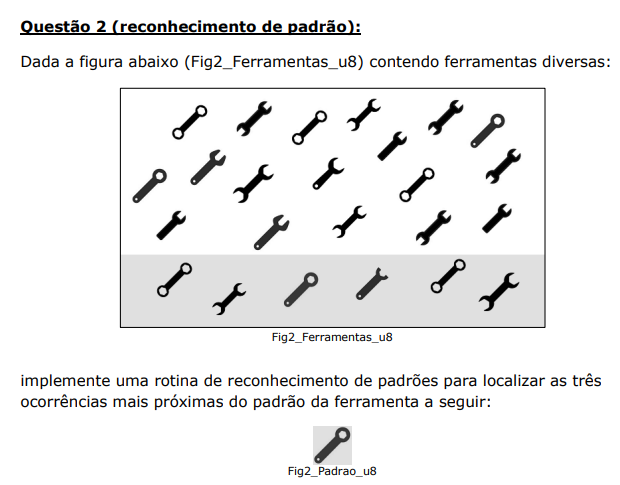

Img_Height    = 360
Img_Width     = 640
Padrao_Height = 56
Padrao_Width  = 56

--- 3 melhores posições ---
Posição 1 -s> (245, 276) Score = 0.0
Posição 2 -s> (526, 37) Score = 50.0
Posição 3 -s> (17, 120) Score = 50.0


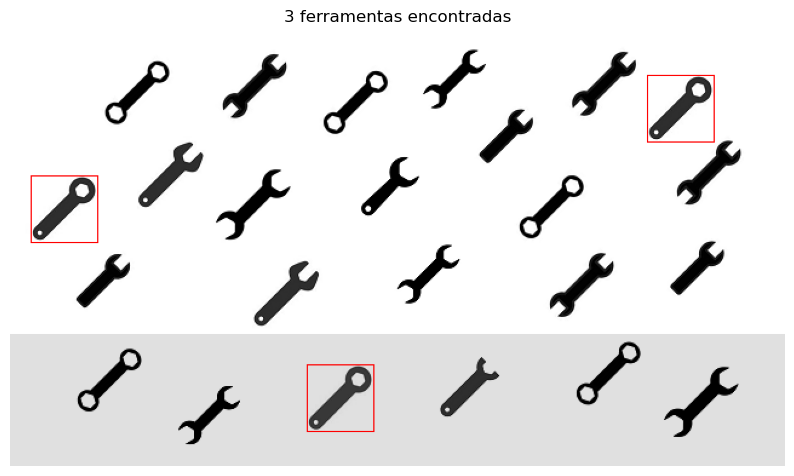

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Funções do Dinho

def Find_N_MaxValues(array_in, N):
	
	"""
	#busca pelos indices dos N maiores valores do array_IN

    Keyword arguments:
    array_in -- nparray 2D de entrada
    N = nro de indexes maximos a serem localizados

    Returns:
    location -- lista dos indexes dos N maiores valores do array_IN

    """

	array_dump = array_in.copy()
	locations = []
	minimum = array_dump.min() - 1
	for i in range(N):
		maxIndex = np.unravel_index(array_dump.argmax(), array_dump.shape)
		locations.append(maxIndex)
		array_dump[maxIndex] = minimum
	    
	return(locations)


def Find_N_MinValues(array_in, N):
	
	"""
	#busca pelos indices dos N menores valores do array_IN

    Keyword arguments:
    array_in -- nparray 2D de entrada
    N = nro de indexes mínimos a serem localizados

    Returns:
    location -- lista dos indexes dos N menores valores do array_IN

    """

	array_dump = array_in.copy()
	locations = []
	maximum = array_dump.max() + 1
	for i in range(N):
		minIndex = np.unravel_index(array_dump.argmin(), array_dump.shape)
		locations.append(minIndex)
		array_dump[minIndex] = maximum
	    
	return(locations)

# =========================
# 1) Leitura das imagens
# =========================
img_u8 = mpimg.imread("Figuras_APS2/Figuras_APS2/Fig2_Ferramentas_u8.bmp")
padrao_u8 = mpimg.imread("Figuras_APS2/Figuras_APS2/Fig2_Padrao_u8.bmp")


img_u8 = img_u8.astype(np.uint8)
padrao_u8 = padrao_u8.astype(np.uint8)

h, w = img_u8.shape
ph, pw = padrao_u8.shape

print("Img_Height    =", h)
print("Img_Width     =", w)
print("Padrao_Height =", ph)
print("Padrao_Width  =", pw)

limiar = 200

img_bin = np.zeros_like(img_u8, dtype=np.uint8)
padrao_bin = np.zeros_like(padrao_u8, dtype=np.uint8)

img_bin[img_u8 < limiar] = 1
padrao_bin[padrao_u8 < limiar] = 1

# =========================
# 2) Função para calcular |bloco - padrão|
# =========================
def MatrizDiffAbs(img_u8, padrao_u8, y, x):

    bloco_u8 = img_u8[y:y+ph, x:x+pw]

    # converte pra tipo com sinal antes de subtrair
    bloco = bloco_u8.astype(np.int16)
    padrao = padrao_u8.astype(np.int16)

    diff = np.abs(bloco - padrao)

    return diff

# =========================
# 3) Matriz para guardar os scores
# =========================
MapaScores = np.zeros((h - ph + 1, w - pw + 1), dtype=np.float64)

# =========================
# 4) Varredura da imagem
# =========================
for y in range(0, h - ph + 1):   # Para o padrão caber na imagem
    for x in range(0, w - pw + 1):   # Para o padrão caber na imagem

        diff = MatrizDiffAbs(img_bin, padrao_bin, y, x)

        # Score simples: soma das diferenças (quanto menor, melhor)
        MD = int(np.sum(diff))

        MapaScores[y, x] = MD

# =========================
# 5) Encontrar as 3 melhores posições
# =========================
MapaScores_aux = MapaScores.copy()
Melhores3 = []

for i in range(3):
    melhor = Find_N_MinValues(MapaScores_aux, 1)[0]
    Melhores3.append(melhor)

    y = melhor[0]
    x = melhor[1]

    y1 = max(0, y - ph//2)
    y2 = min(MapaScores_aux.shape[0], y + ph//2)
    x1 = max(0, x - pw//2)
    x2 = min(MapaScores_aux.shape[1], x + pw//2)

    MapaScores_aux[y1:y2, x1:x2] = MapaScores_aux.max() + 1

print("\n--- 3 melhores posições ---")
for i in range(len(Melhores3)):
    y = Melhores3[i][0]
    x = Melhores3[i][1]
    print("Posição", i+1, "-s>", (x, y), "Score =", MapaScores[y, x])

# =========================
# 6) Desenhar 3 retângulos vermelhos
# =========================
img_rgb = np.dstack((img_u8, img_u8, img_u8)).astype(np.uint8)

for i in range(len(Melhores3)):
    y = Melhores3[i][0]
    x = Melhores3[i][1]

    # linha de cima
    img_rgb[y, x:x+pw, 0] = 255
    img_rgb[y, x:x+pw, 1] = 0
    img_rgb[y, x:x+pw, 2] = 0

    # linha de baixo
    img_rgb[y+ph-1, x:x+pw, 0] = 255
    img_rgb[y+ph-1, x:x+pw, 1] = 0
    img_rgb[y+ph-1, x:x+pw, 2] = 0

    # linha da esquerda
    img_rgb[y:y+ph, x, 0] = 255
    img_rgb[y:y+ph, x, 1] = 0
    img_rgb[y:y+ph, x, 2] = 0

    # linha da direita
    img_rgb[y:y+ph, x+pw-1, 0] = 255
    img_rgb[y:y+ph, x+pw-1, 1] = 0
    img_rgb[y:y+ph, x+pw-1, 2] = 0

# =========================
# 7) Mostrar resultado final
# =========================
plt.figure(figsize=(10, 6))
plt.title("3 ferramentas encontradas")
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

___
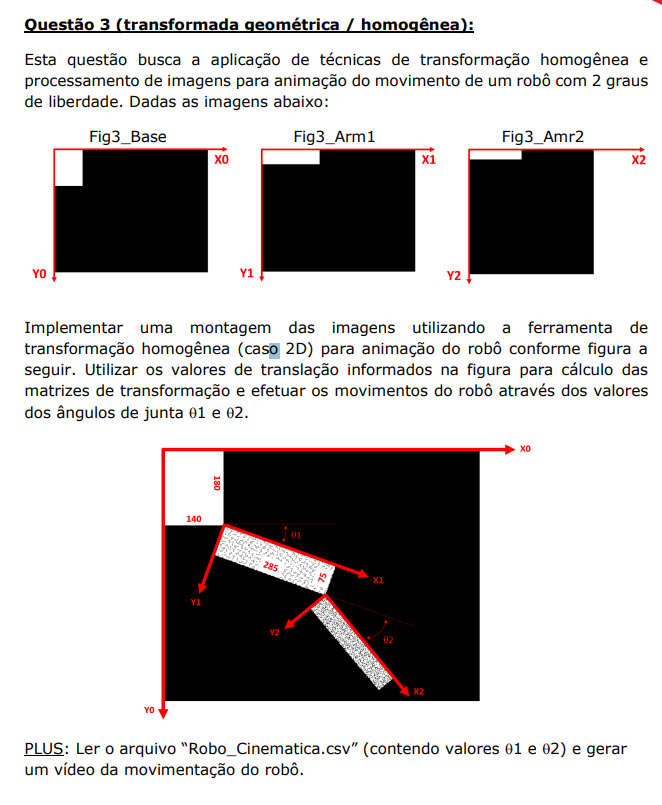

Base  -> (600, 750)
Arm1  -> (600, 750)
Arm2  -> (600, 600)

Origens locais escolhidas:
Arm1 -> (0, 0.0)
Arm2 -> (0, 0.0)


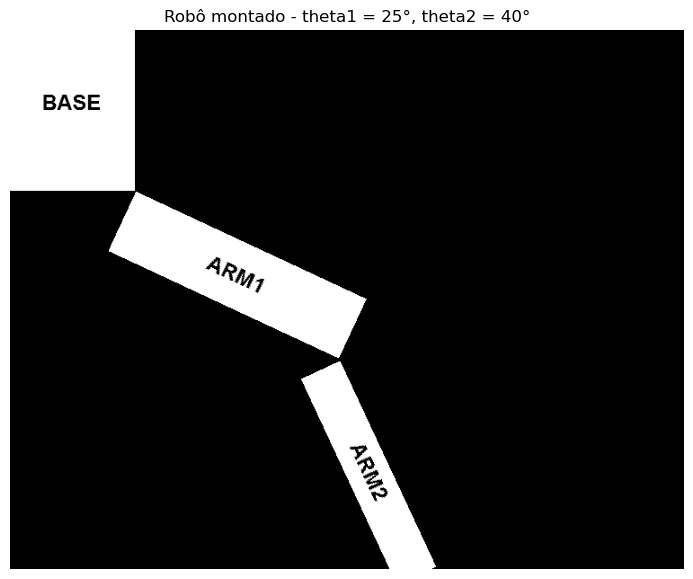


Quantidade de poses no CSV = 16
Primeiras poses = [(0.0, 0.0), (0.0, 15.0), (0.0, 30.0), (0.0, 45.0), (10.0, 45.0)]


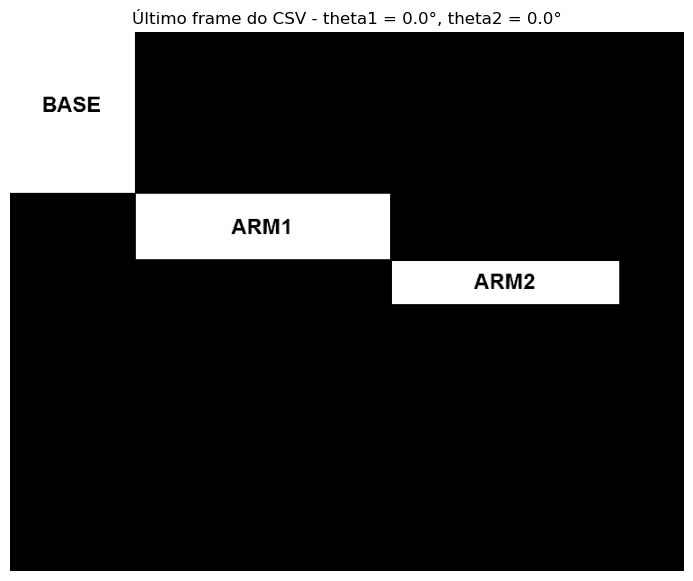

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# 1) Leitura das imagens
# ============================================================
img_base = mpimg.imread("Figuras_APS2/Figuras_APS2/Fig3_Base.bmp")
img_arm1 = mpimg.imread("Figuras_APS2/Figuras_APS2/Fig3_Arm1.bmp")
img_arm2 = mpimg.imread("Figuras_APS2/Figuras_APS2/Fig3_Arm2.bmp")

# Se a imagem vier em float (valores entre 0 e 1), converte para uint8 (0 a 255)
if img_base.dtype != np.uint8:
    img_base = (255 * img_base).astype(np.uint8)

if img_arm1.dtype != np.uint8:
    img_arm1 = (255 * img_arm1).astype(np.uint8)

if img_arm2.dtype != np.uint8:
    img_arm2 = (255 * img_arm2).astype(np.uint8)

# Se a imagem vier RGB, pega só um canal (em geral elas já são cinza)
if len(img_base.shape) == 3:
    img_base = img_base[:, :, 0]

if len(img_arm1.shape) == 3:
    img_arm1 = img_arm1[:, :, 0]

if len(img_arm2.shape) == 3:
    img_arm2 = img_arm2[:, :, 0]

hb, wb = img_base.shape
h1, w1 = img_arm1.shape
h2, w2 = img_arm2.shape

print("Base  ->", img_base.shape)
print("Arm1  ->", img_arm1.shape)
print("Arm2  ->", img_arm2.shape)

# ============================================================
# 2) Origens locais das peças
# ============================================================
# Aqui definimos manualmente a origem local de cada braço.
# Essa origem é a junta da peça, isto é, o vértice inferior direito
# do quadrado branco desenhado no canto superior esquerdo.


origem1_x = 0
origem1_y = origem1_x * 180/140

origem2_x = 0
origem2_y = origem2_x * 180/140

print("\nOrigens locais escolhidas:")
print("Arm1 ->", (origem1_x, origem1_y))
print("Arm2 ->", (origem2_x, origem2_y))

# ============================================================
# 3) Funções de transformação homogênea 2D
# ============================================================
def TH_Translacao(tx, ty):

    TH = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=float)

    return TH


def TH_Rotacao(angulo_graus):

    # Em imagem, o eixo y cresce para baixo.
    # Esta convenção faz o braço girar no sentido visual esperado.
    ang = np.deg2rad(angulo_graus)

    c = np.cos(ang)
    s = np.sin(ang)

    TH = np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=float)

    return TH

# ============================================================
# 4) Função para aplicar a transformação homogênea
# ============================================================
def AplicaTransformacaoHomogenea(img_in, img_out, TH_01):

    # Fazemos a transformação inversa:
    # para cada pixel da saída, descobrimos de qual pixel da entrada ele veio
    TH_10 = np.linalg.inv(TH_01)

    h_in, w_in = img_in.shape
    h_out, w_out = img_out.shape

    for y_out in range(h_out):
        for x_out in range(w_out):

            p_out = np.array([[x_out], [y_out], [1]], dtype=float)
            p_in = np.matmul(TH_10, p_out)

            x_in = int(round(p_in[0, 0] / p_in[2, 0]))
            y_in = int(round(p_in[1, 0] / p_in[2, 0]))

            if x_in in range(w_in) and y_in in range(h_in):

                pixel = img_in[y_in, x_in]

                # Só copia se não for fundo preto
                if pixel > 0:
                    img_out[y_out, x_out] = pixel

    return img_out

# ============================================================
# 5) Dados geométricos do enunciado
# ============================================================
# Base -> Arm1
tx01 = 140
ty01 = 180

# Arm1 -> Arm2
tx12 = 285
ty12 = 75

# ============================================================
# 6) Função para montar o robô
# ============================================================
def MontaRobo(theta1, theta2):

    # Começamos com a base como imagem final
    img_out = img_base.copy()

    # --------------------------------------------------------
    # Arm1
    # --------------------------------------------------------
    # A sequência é:
    # 1) levar a junta local do arm1 para a origem
    # 2) girar de theta1
    # 3) levar a peça até a junta da base (140,180)
    TH_arm1 = np.matmul(
        TH_Translacao(tx01, ty01),
        np.matmul(
            TH_Rotacao(theta1),
            TH_Translacao(-origem1_x, -origem1_y)
        )
    )

    # --------------------------------------------------------
    # Arm2
    # --------------------------------------------------------
    # O arm2 é definido no referencial do arm1.
    # A sequência é:
    # 1) levar a junta local do arm2 para a origem
    # 2) girar de theta2
    # 3) levar até a junta do arm1 (285,70)
    # 4) aplicar a rotação do arm1
    # 5) levar tudo até a junta da base (140,180)
    TH_arm2 = np.matmul(
        TH_Translacao(tx01, ty01),
        np.matmul(
            TH_Rotacao(theta1),
            np.matmul(
                TH_Translacao(tx12, ty12),
                np.matmul(
                    TH_Rotacao(theta2),
                    TH_Translacao(-origem2_x, -origem2_y)
                )
            )
        )
    )

    # Aplica as duas peças na imagem final
    img_out = AplicaTransformacaoHomogenea(img_arm1, img_out, TH_arm1)
    img_out = AplicaTransformacaoHomogenea(img_arm2, img_out, TH_arm2)

    return img_out

# ============================================================
# 7) Teste com uma pose única
# ============================================================
theta1 = 25
theta2 = 40

img_robo = MontaRobo(theta1, theta2)

plt.figure(figsize=(10, 7))
plt.title(f"Robô montado - theta1 = {theta1}°, theta2 = {theta2}°")
plt.imshow(img_robo, cmap="gray")
plt.axis("off")
plt.show()

# ============================================================
# 8) Ler o arquivo Robo_Cinematica.csv
# ============================================================
# Leitura simples, linha por linha, sem usar pandas.

ListaAngulos = []

with open("Robo_Cinematica.csv", "r", encoding="utf-8") as arq:
    linhas = arq.readlines()

for linha in linhas:

    linha = linha.strip()

    if linha != "":

        if ";" in linha:
            partes = linha.split(";")
        else:
            partes = linha.split(",")

        partes = [p.strip() for p in partes]

        try:
            theta1_csv = float(partes[0].replace(",", "."))
            theta2_csv = float(partes[1].replace(",", "."))
            ListaAngulos.append((theta1_csv, theta2_csv))
        except:
            pass

print("\nQuantidade de poses no CSV =", len(ListaAngulos))
print("Primeiras poses =", ListaAngulos[:5])

# ============================================================
# 9) Mostrar somente o último frame do CSV
# ============================================================
if len(ListaAngulos) > 0:

    theta1_final = ListaAngulos[-1][0]
    theta2_final = ListaAngulos[-1][1]

    img_final = MontaRobo(theta1_final, theta2_final)

    plt.figure(figsize=(10, 7))
    plt.title(f"Último frame do CSV - theta1 = {theta1_final}°, theta2 = {theta2_final}°")
    plt.imshow(img_final, cmap="gray")
    plt.axis("off")
    plt.show()

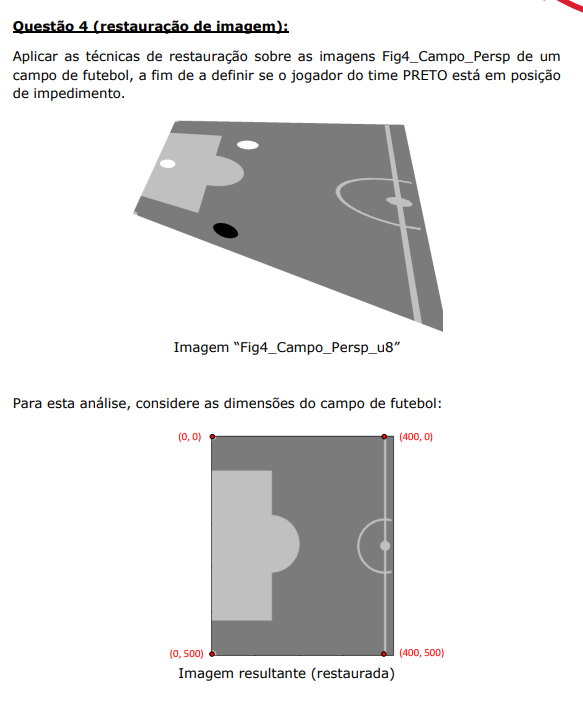


Arquivo = Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp1a.bmp
Shape   = (500, 700)

Cantos estimados na imagem original:
[[102.  12.]
 [602.  23.]
 [  6. 219.]
 [691. 480.]]

Homografia H =
[[ 1.65672144e+00  7.68334583e-01 -1.78205602e+02]
 [-8.07029058e-02  3.66831390e+00 -3.57880704e+01]
 [ 1.72261747e-03  2.39196899e-03  1.00000000e+00]]

Jogador preto:
Centro = (288.56895193065407, 448.1103230890465) Área = 1269

Figuras brancas detectadas:
Branco 1 -> centro = (189.28616600790514, 115.45612648221343) Área = 1265
Branco 2 -> centro = (30.357620817843866, 252.03643122676579) Área = 1345

Quantidade de figuras brancas à esquerda do preto = 2
Resultado: JOGADOR PRETO EM POSIÇÃO LEGAL


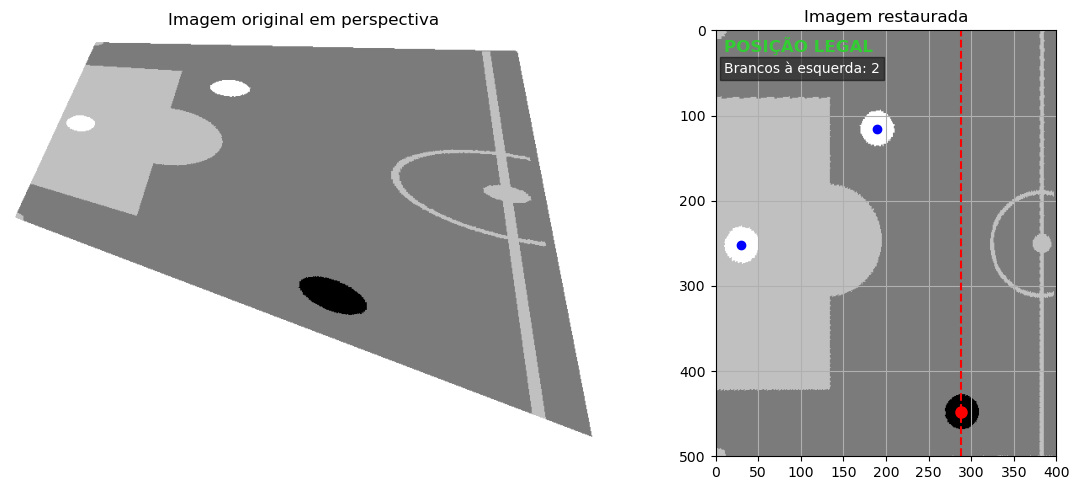


Arquivo = Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp2a.bmp
Shape   = (500, 700)

Cantos estimados na imagem original:
[[102.  12.]
 [602.  23.]
 [  6. 219.]
 [691. 480.]]

Homografia H =
[[ 1.65672144e+00  7.68334583e-01 -1.78205602e+02]
 [-8.07029058e-02  3.66831390e+00 -3.57880704e+01]
 [ 1.72261747e-03  2.39196899e-03  1.00000000e+00]]

Jogador preto:
Centro = (168.13365155131265, 449.51630867143996) Área = 1257

Figuras brancas detectadas:
Branco 1 -> centro = (189.28616600790514, 115.45612648221343) Área = 1265
Branco 2 -> centro = (30.357620817843866, 252.03643122676579) Área = 1345

Quantidade de figuras brancas à esquerda do preto = 1
Resultado: JOGADOR PRETO EM IMPEDIMENTO


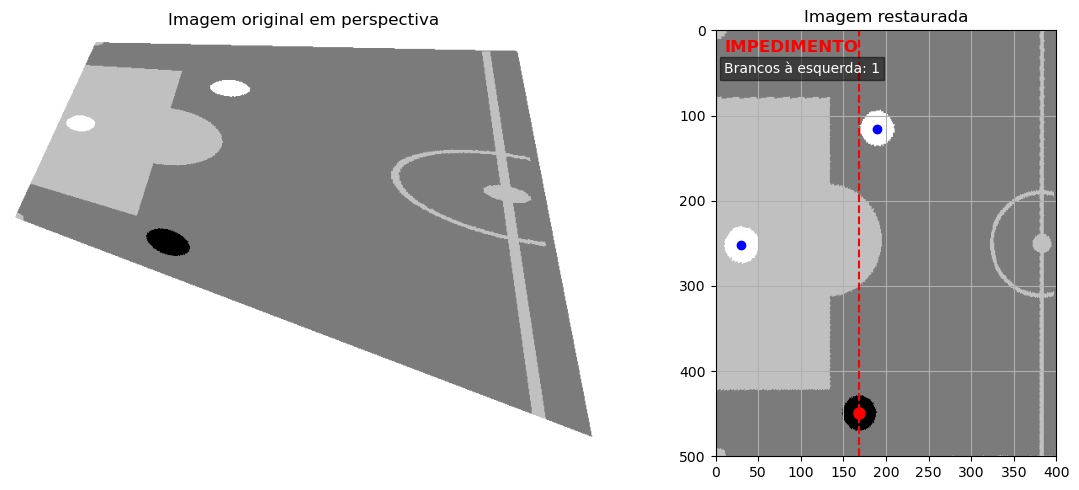


Arquivo = Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp3a.bmp
Shape   = (500, 700)

Cantos estimados na imagem original:
[[102.  12.]
 [602.  23.]
 [  6. 219.]
 [691. 480.]]

Homografia H =
[[ 1.65672144e+00  7.68334583e-01 -1.78205602e+02]
 [-8.07029058e-02  3.66831390e+00 -3.57880704e+01]
 [ 1.72261747e-03  2.39196899e-03  1.00000000e+00]]

Jogador preto:
Centro = (185.51332288401255, 449.4239811912226) Área = 1276

Figuras brancas detectadas:
Branco 1 -> centro = (189.28616600790514, 115.45612648221343) Área = 1265
Branco 2 -> centro = (30.357620817843866, 252.03643122676579) Área = 1345

Quantidade de figuras brancas à esquerda do preto = 1
Resultado: JOGADOR PRETO EM IMPEDIMENTO


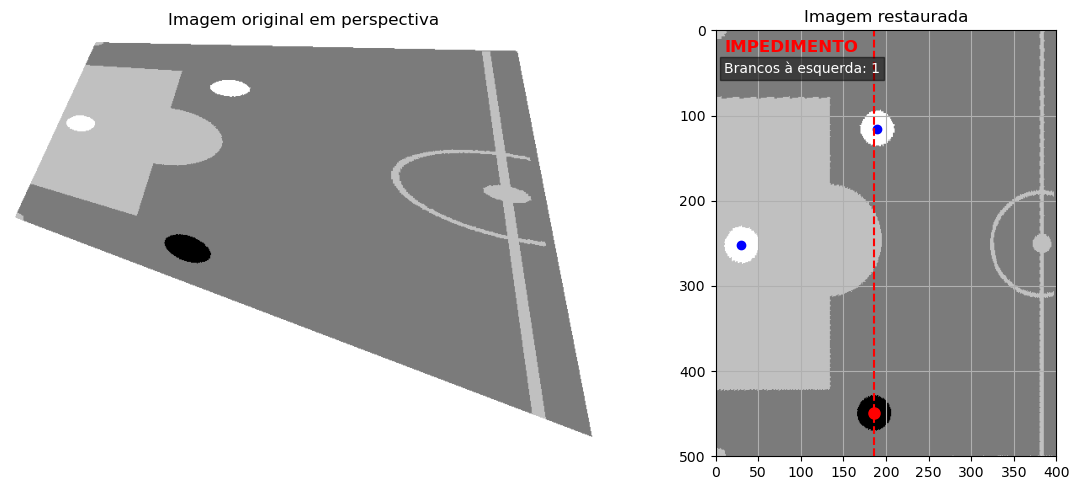


Arquivo = Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp4.bmp
Shape   = (500, 700)

Cantos estimados na imagem original:
[[102.  12.]
 [602.  23.]
 [  6. 219.]
 [691. 480.]]

Homografia H =
[[ 1.65672144e+00  7.68334583e-01 -1.78205602e+02]
 [-8.07029058e-02  3.66831390e+00 -3.57880704e+01]
 [ 1.72261747e-03  2.39196899e-03  1.00000000e+00]]

Jogador preto:
Centro = (288.56895193065407, 448.1103230890465) Área = 1269

Figuras brancas detectadas:
Branco 1 -> centro = (189.28616600790514, 115.45612648221343) Área = 1265

Quantidade de figuras brancas à esquerda do preto = 1
Resultado: JOGADOR PRETO EM POSIÇÃO LEGAL


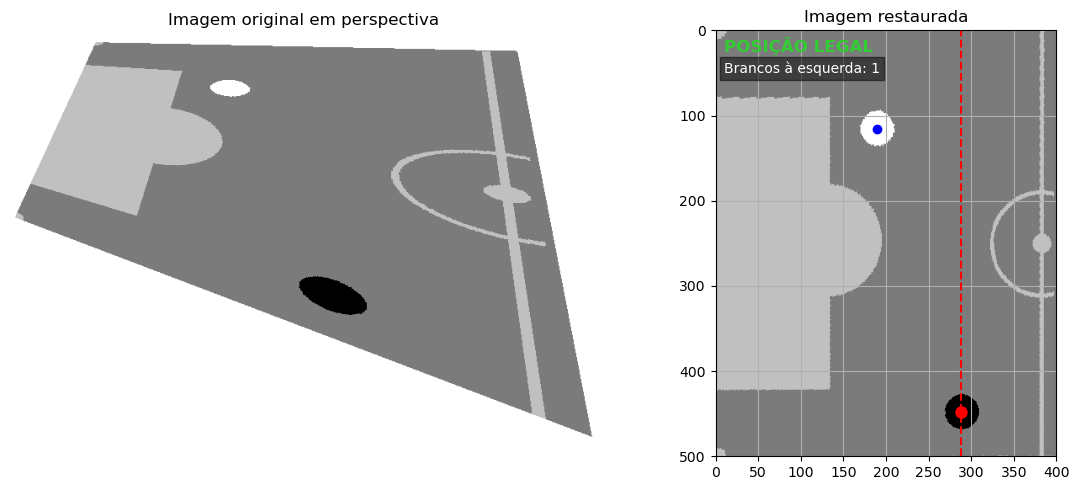


================ RESUMO FINAL ================

Arquivo: Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp1a.bmp
Brancos à esquerda: 2
Conclusão: POSIÇÃO LEGAL

Arquivo: Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp2a.bmp
Brancos à esquerda: 1
Conclusão: IMPEDIMENTO

Arquivo: Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp3a.bmp
Brancos à esquerda: 1
Conclusão: IMPEDIMENTO

Arquivo: Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp4.bmp
Brancos à esquerda: 1
Conclusão: POSIÇÃO LEGAL


In [47]:
# ============================================================
# 1) Dimensões desejadas da imagem restaurada
# ============================================================
# O enunciado pede um campo restaurado com:
# (0,0), (400,0), (0,500), (400,500)

LarguraCampo = 400
AlturaCampo = 500

# Como as coordenadas vão de 0 até 400 e de 0 até 500,
# a imagem final terá 401 colunas e 501 linhas.
w_out = LarguraCampo + 1
h_out = AlturaCampo + 1

# ============================================================
# 2) Função para encontrar os 4 cantos do campo na imagem em perspectiva
# ============================================================
# - o campo é a grande região cinza da imagem
# - fazemos uma máscara do campo
# - pegamos todos os pixels dessa região
# - estimamos os cantos pelos extremos de soma e diferença

def EstimaCantosCampo(img_u8):

    mascara = img_u8 < 210

    ys, xs = np.where(mascara)

    if len(xs) == 0:
        raise RuntimeError("Não consegui localizar a região do campo")

    pts = np.zeros((len(xs), 2), dtype=float)
    pts[:, 0] = xs
    pts[:, 1] = ys

    soma = pts[:, 0] + pts[:, 1]
    diferenca = pts[:, 0] - pts[:, 1]

    canto_tl = pts[np.argmin(soma)]
    canto_br = pts[np.argmax(soma)]
    canto_tr = pts[np.argmax(diferenca)]
    canto_bl = pts[np.argmin(diferenca)]

    src = np.array([
        [canto_tl[0], canto_tl[1]],
        [canto_tr[0], canto_tr[1]],
        [canto_bl[0], canto_bl[1]],
        [canto_br[0], canto_br[1]]
    ], dtype=float)

    return src

# ============================================================
# 3) Função para calcular a homografia
# ============================================================
# Fazemos isso pelo método clássico com SVD.

def CalculaHomografia(src_pts, dst_pts):

    A = []

    for i in range(4):
        x = src_pts[i, 0]
        y = src_pts[i, 1]

        u = dst_pts[i, 0]
        v = dst_pts[i, 1]

        A.append([x, y, 1, 0, 0, 0, -u*x, -u*y, -u])
        A.append([0, 0, 0, x, y, 1, -v*x, -v*y, -v])

    A = np.array(A, dtype=float)

    U, S, VT = np.linalg.svd(A)

    H = VT[-1].reshape((3, 3))
    H = H / H[2, 2]

    return H

# ============================================================
# 4) Função para restaurar a imagem
# ============================================================
# Usamos transformação inversa:
# para cada pixel da imagem restaurada, descobrimos de onde ele veio
# na imagem original em perspectiva.

def RestauraImagem(img_in, H, h_out, w_out):

    H_inv = np.linalg.inv(H)

    h_in, w_in = img_in.shape

    # fundo claro parecido com o do enunciado
    img_out = np.ones((h_out, w_out), dtype=np.uint8) * 220

    for y_out in range(h_out):
        for x_out in range(w_out):

            p_out = np.array([[x_out], [y_out], [1]], dtype=float)
            p_in = np.matmul(H_inv, p_out)

            u = int(round(p_in[0, 0] / p_in[2, 0]))
            v = int(round(p_in[1, 0] / p_in[2, 0]))

            if u in range(w_in) and v in range(h_in):
                img_out[y_out, x_out] = img_in[v, u]

    return img_out

# ============================================================
# 5) Função para rotular componentes conexos
# ============================================================
# Fazemos uma versão simples "na mão", usando pilha.

def ComponentesConexos(mascara_bin):

    h, w = mascara_bin.shape

    rotulos = np.zeros((h, w), dtype=np.int32)
    rotulo_atual = 0

    for y0 in range(h):
        for x0 in range(w):

            if mascara_bin[y0, x0] == 1 and rotulos[y0, x0] == 0:

                rotulo_atual += 1
                pilha = [(y0, x0)]
                rotulos[y0, x0] = rotulo_atual

                while len(pilha) > 0:
                    y, x = pilha.pop()

                    vizinhos = [
                        (y-1, x),
                        (y+1, x),
                        (y, x-1),
                        (y, x+1)
                    ]

                    for yn, xn in vizinhos:
                        if yn in range(h) and xn in range(w):
                            if mascara_bin[yn, xn] == 1 and rotulos[yn, xn] == 0:
                                rotulos[yn, xn] = rotulo_atual
                                pilha.append((yn, xn))

    return rotulos, rotulo_atual

# ============================================================
# 6) Função para obter centro e área dos componentes
# ============================================================
def PropriedadesComponentes(rotulos, n_rotulos):

    ListaProps = []

    for k in range(1, n_rotulos + 1):

        ys, xs = np.where(rotulos == k)

        if len(xs) > 0:
            area = len(xs)
            x_centro = np.mean(xs)
            y_centro = np.mean(ys)

            ListaProps.append({
                "rotulo": k,
                "area": area,
                "x": x_centro,
                "y": y_centro
            })

    return ListaProps

# ============================================================
# 7) Detectar jogador preto
# ============================================================
# O jogador preto vira uma mancha bem escura.
# Pegamos o maior componente escuro com área razoável.

def DetectaJogadorPreto(img_rest):

    mascara_preto = np.zeros_like(img_rest, dtype=np.uint8)
    mascara_preto[img_rest < 60] = 1

    rotulos, n_rotulos = ComponentesConexos(mascara_preto)
    props = PropriedadesComponentes(rotulos, n_rotulos)

    melhor = None
    maior_area = -1

    for p in props:
        if p["area"] > maior_area:
            maior_area = p["area"]
            melhor = p

    if melhor is None:
        raise RuntimeError("Não consegui detectar o jogador preto")

    return melhor

# ============================================================
# 8) Detectar figuras brancas
# ============================================================
# As figuras brancas ficam muito claras após a restauração.
# Pegamos componentes claros com área intermediária.

def DetectaFigurasBrancas(img_rest):

    mascara_branco = np.zeros_like(img_rest, dtype=np.uint8)
    mascara_branco[img_rest > 235] = 1

    rotulos, n_rotulos = ComponentesConexos(mascara_branco)
    props = PropriedadesComponentes(rotulos, n_rotulos)

    ListaBrancos = []

    for p in props:

        area = p["area"]

        # Faixa simples para evitar pegar linhas e regiões muito grandes
        if area >= 80 and area <= 3000:
            ListaBrancos.append(p)

    return ListaBrancos

# ============================================================
# 9) Função principal para processar uma perspectiva
# ============================================================
def ProcessaPerspectiva(NomeArquivo):

    # --------------------------------------------------------
    # Leitura da imagem
    # --------------------------------------------------------
    img_u8 = mpimg.imread(NomeArquivo)

    # Se a imagem vier em float (valores entre 0 e 1), converte para uint8 (0 a 255)
    if img_u8.dtype != np.uint8:
        img_u8 = (255 * img_u8).astype(np.uint8)

    # Se a imagem vier RGB, pega só um canal (em geral ela já é cinza)
    if len(img_u8.shape) == 3:
        img_u8 = img_u8[:, :, 0]

    print("\n====================================================")
    print("Arquivo =", NomeArquivo)
    print("Shape   =", img_u8.shape)

    # --------------------------------------------------------
    # Restaurar a imagem
    # --------------------------------------------------------
    src_pts = EstimaCantosCampo(img_u8)

    dst_pts = np.array([
        [0, 0],
        [LarguraCampo, 0],
        [0, AlturaCampo],
        [LarguraCampo, AlturaCampo]
    ], dtype=float)

    print("\nCantos estimados na imagem original:")
    print(src_pts)

    H = CalculaHomografia(src_pts, dst_pts)

    print("\nHomografia H =")
    print(H)

    img_rest = RestauraImagem(img_u8, H, h_out, w_out)

    # --------------------------------------------------------
    # Análise de impedimento
    # --------------------------------------------------------
    JogadorPreto = DetectaJogadorPreto(img_rest)
    FigurasBrancas = DetectaFigurasBrancas(img_rest)

    x_preto = JogadorPreto["x"]
    y_preto = JogadorPreto["y"]

    BrancosEsquerda = []

    for p in FigurasBrancas:
        if p["x"] < x_preto:
            BrancosEsquerda.append(p)

    QtdEsquerda = len(BrancosEsquerda)

    # Seguindo exatamente o que eu entendo como impedimento:
    
# - se houver 2 ou mais brancos à esquerda do preto, posição legal
# - se houver 0 brancos à esquerda do preto, impedimento
# - se houver exatamente 1 branco no total, impedimento se o preto estiver à esquerda dele

    if QtdEsquerda >= 2:
        EmImpedimento = False

    elif len(FigurasBrancas) == 1:
        branco_unico = FigurasBrancas[0]

        if x_preto < branco_unico["x"]:
            EmImpedimento = True
        else:
            EmImpedimento = False

    else:
        EmImpedimento = True

    print("\nJogador preto:")
    print("Centro =", (x_preto, y_preto), "Área =", JogadorPreto["area"])

    print("\nFiguras brancas detectadas:")
    for i in range(len(FigurasBrancas)):
        p = FigurasBrancas[i]
        print("Branco", i+1, "-> centro =", (p["x"], p["y"]), "Área =", p["area"])

    print("\nQuantidade de figuras brancas à esquerda do preto =", QtdEsquerda)

    if EmImpedimento:
        print("Resultado: JOGADOR PRETO EM IMPEDIMENTO")
    else:
        print("Resultado: JOGADOR PRETO EM POSIÇÃO LEGAL")

    # --------------------------------------------------------
    # Mostrar resultado
    # --------------------------------------------------------
    plt.figure(figsize=(12, 5))

    # Imagem original
    plt.subplot(1, 2, 1)
    plt.imshow(img_u8, cmap="gray", vmin=0, vmax=255)
    plt.title("Imagem original em perspectiva")
    plt.axis("off")

    # Imagem restaurada
    plt.subplot(1, 2, 2)
    plt.imshow(img_rest, cmap="gray", vmin=0, vmax=255)
    plt.title("Imagem restaurada")
    plt.xlim(0, LarguraCampo)
    plt.ylim(AlturaCampo, 0)

    # Marca o jogador preto
    plt.plot(x_preto, y_preto, "ro", markersize=8)

    # Marca as figuras brancas
    for p in FigurasBrancas:
        plt.plot(p["x"], p["y"], "bo", markersize=6)

    # Linha vertical do jogador preto
    plt.axvline(x_preto, color="red", linestyle="--", linewidth=1.5)

    TextoStatus = "IMPEDIMENTO" if EmImpedimento else "POSIÇÃO LEGAL"
    CorStatus = "red" if EmImpedimento else "limegreen"

    plt.text(10, 25, TextoStatus, color=CorStatus, fontsize=12, fontweight="bold")
    plt.text(10, 50, f"Brancos à esquerda: {QtdEsquerda}", color="white",
             fontsize=10, bbox=dict(facecolor="black", alpha=0.5, pad=3))

    plt.grid()
    plt.tight_layout()
    plt.show()

    return {
        "arquivo": NomeArquivo,
        "img_rest": img_rest,
        "x_preto": x_preto,
        "y_preto": y_preto,
        "qtd_brancos_esquerda": QtdEsquerda,
        "impedimento": EmImpedimento
    }

# ============================================================
# 10) Lista das 4 perspectivas
# ============================================================
# Troque os nomes abaixo para os nomes exatos dos seus 4 arquivos.

ListaPerspectivas = [
    "Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp1a.bmp",
    "Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp2a.bmp",
    "Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp3a.bmp",
    "Figuras_APS2/Figuras_APS2/Fig4_Campo_Persp4.bmp"
]

# ============================================================
# 11) Rodar as 4 perspectivas
# ============================================================
Resultados = []

for NomeArquivo in ListaPerspectivas:
    ResultadoAtual = ProcessaPerspectiva(NomeArquivo)
    Resultados.append(ResultadoAtual)

# ============================================================
# 12) Resumo final
# ============================================================
print("\n================ RESUMO FINAL ================")

for r in Resultados:
    print("\nArquivo:", r["arquivo"])
    print("Brancos à esquerda:", r["qtd_brancos_esquerda"])

    if r["impedimento"]:
        print("Conclusão: IMPEDIMENTO")
    else:
        print("Conclusão: POSIÇÃO LEGAL")